# 0b. Interactive BE Parameter Explorer: Update Matrix

Explore how BE model parameters affect the update matrix (serial dependence pattern).

Use the sliders to adjust parameters and see real-time changes in:
- Update matrix heatmap
- Serial dependence profile
- Psychometric curve

---

## Key Parameters

| Parameter | Description | Effect on Update Matrix |
|-----------|-------------|-------------------------|
| `sigma_percep` | Perceptual noise | Higher â†’ noisier decisions, smoother update matrix |
| `A_repulsion` | Serial dependence (repulsion) | Higher â†’ stronger off-diagonal structure |
| `eta_learning` | Learning rate | Higher â†’ stronger serial dependence (larger values) |
| `eta_relax` | Relaxation rate | Higher â†’ faster forgetting, weaker patterns |

---

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Interactive widgets
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, FloatSlider, IntSlider, Dropdown, HBox, VBox
from IPython.display import display, clear_output

# Core utilities
from Helpers.utils import generate_stimuli

# Models
from Models.BE_core import BEParams, BEState, BEModel

# Analysis
from Analysis.update_matrix import compute_update_matrix, compute_update_matrix_from_history

print("Imports successful!")

Imports successful!


In [2]:
# =============================================================================
# GLOBAL SETTINGS
# =============================================================================

N_TRIALS = 20000
BURN_IN = 1000
SEED = 42
N_BINS = 8

# Pre-generate stimuli (same for all parameter combinations)
STIMULI, CATEGORIES, _ = generate_stimuli(n_trials=N_TRIALS, seed=SEED)

print(f"Settings: {N_TRIALS} trials, {BURN_IN} burn-in, {N_BINS} bins")
print(f"Stimuli generated with seed {SEED}")

Settings: 20000 trials, 1000 burn-in, 8 bins
Stimuli generated with seed 42


In [3]:
params = BEParams(
	sigma_percep=0.2,
	A_repulsion=0.3,
	eta_learning=0.5,
	eta_relax=0.1
	)

# Create initial state with burn-in
initial_state = BEModel.create_initial_state(
	burn_in=BURN_IN, params=params, seed=42
)

# Simulate
rng = np.random.default_rng(42)
choices, p_B, final_state, history = BEModel.simulate_session(
	params, initial_state, STIMULI, CATEGORIES, rng,
	return_history=True
)

# Compute update matrix
update_matrix, conditional_matrix, info = compute_update_matrix_from_history(
	history,
	n_bins=N_BINS,
	trial_filter='all'
)

In [4]:
print("Bin counts:", info.get('bin_counts'))
print("lapse_low:", info['total_psychometric']['lapse_low'])
print("lapse_high:", info['total_psychometric']['lapse_high'])

Bin counts: [2466 2578 2468 2425 2529 2566 2476 2491]
lapse_low: 0.13770648837256177
lapse_high: 0.19564146461674184


In [5]:
# =============================================================================
# CORE COMPUTATION FUNCTION
# =============================================================================

def compute_update_matrix_for_params(
	sigma_percep: float,
	A_repulsion: float,
	eta_learning: float,
	eta_relax: float,
	seed: int = SEED
):
	"""
	Simulate with given parameters and compute update matrix.
	
	Returns:
		update_matrix, conditional_matrix, choices, p_B, accuracy, info
	"""
	# Create parameters
	params = BEParams(
		sigma_percep=sigma_percep,
		A_repulsion=A_repulsion,
		eta_learning=eta_learning,
		eta_relax=eta_relax
	)
	
	# Create initial state with burn-in
	initial_state = BEModel.create_initial_state(
		burn_in=BURN_IN, params=params, seed=seed
	)
	
	# Simulate
	rng = np.random.default_rng(seed)
	choices, p_B, final_state, history = BEModel.simulate_session(
		params, initial_state, STIMULI, CATEGORIES, rng,
		return_history=True
	)
	
	# Compute update matrix
	update_matrix, conditional_matrix, info = compute_update_matrix_from_history(
		history,
		n_bins=N_BINS,
		trial_filter='all'
	)
	
	# Compute accuracy
	accuracy = np.nanmean(choices == CATEGORIES)
	
	return update_matrix, conditional_matrix, choices, p_B, accuracy, info

## Interactive Explorer

Adjust the sliders to see how each parameter affects the update matrix.

In [6]:
# =============================================================================
# INTERACTIVE PLOTTING FUNCTION
# =============================================================================

import matplotlib.colors as mcolors
um_cmap = mcolors.LinearSegmentedColormap.from_list(
	'custom_diverging',
	[(253/255, 120/255, 6/255), (1, 1, 1), (120/255, 0/255, 220/255)]
)

def plot_update_matrix_interactive(
	sigma_percep: float,
	A_repulsion: float,
	eta_learning: float,
	eta_relax: float,
	show_psychometric: bool = True
):
	"""
	Interactive plotting function for update matrix exploration.
	"""
	# Compute
	update_matrix, conditional_matrix, choices, p_B, accuracy, info = compute_update_matrix_for_params(
		sigma_percep, A_repulsion, eta_learning, eta_relax
	)
	print(f"Computed update matrix for parameters: sigma={sigma_percep}, A={A_repulsion}, eta_learning={eta_learning}, eta_relax={eta_relax}")
	# Create figure
	if show_psychometric:
		fig = plt.figure(figsize=(16, 5))
		gs = fig.add_gridspec(1, 4, width_ratios=[1.2, 1, 1, 1])
		ax1 = fig.add_subplot(gs[0])
		ax2 = fig.add_subplot(gs[1])
		ax3 = fig.add_subplot(gs[2])
		ax4 = fig.add_subplot(gs[3])
	else:
		fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
	
	# === Panel 1: Update Matrix ===
	vmax = np.nanmax(np.abs(update_matrix))
	if np.isnan(vmax) or vmax == 0:
		vmax = 0.3
	
	im = ax1.imshow(update_matrix, cmap=um_cmap, vmin=-vmax, vmax=vmax,
					origin='lower', aspect='equal')
	ax1.set_xlabel('Previous stimulus bin')
	ax1.set_ylabel('Current stimulus bin')
	ax1.set_title('Update Matrix')
	ax1.set_xticks([0, 3.5, 7])
	ax1.set_xticklabels(['-1', '0', '1'])
	ax1.set_yticks([0, 3.5, 7])
	ax1.set_yticklabels(['-1', '0', '1'])
	plt.colorbar(im, ax=ax1, label=r'$\Delta$P(B)')
	
	# === Panel 2: Serial Dependence Profile ===
	profile = np.nanmean(update_matrix, axis=0)
	bin_indices = np.arange(N_BINS) + 1
	colors = plt.cm.RdBu_r(np.linspace(0.1, 0.9, N_BINS))
	ax2.bar(bin_indices, profile, color=colors, edgecolor='black', linewidth=0.5)
	ax2.axhline(0, color='k', linestyle='-', alpha=0.3)
	ax2.set_xlabel('Previous stimulus bin')
	ax2.set_ylabel(r'Mean $\Delta$P(B)')
	ax2.set_title('Serial Dependence Profile')
	ax2.set_xticks(bin_indices)
	
	# === Panel 3: Conditional Psychometrics ===
	midpoints = info.get('midpoints', np.linspace(-0.875, 0.875, N_BINS))
	overall = info.get('overall_curve', info.get('total_curve', np.nanmean(conditional_matrix, axis=1)))
	
	# Plot overall
	ax3.plot(midpoints, overall, 'k-', linewidth=2.5, label='Overall', zorder=10)
	
	# Plot conditional curves
	cmap = plt.cm.coolwarm(np.linspace(0.1, 0.9, N_BINS))
	for j in range(N_BINS):
		curve = conditional_matrix[:, j]
		if not np.all(np.isnan(curve)):
			ax3.plot(midpoints, curve, '-', color=cmap[j], linewidth=1, alpha=0.7)
	
	ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
	ax3.axvline(0, color='gray', linestyle='--', alpha=0.5)
	ax3.set_xlabel('Current stimulus')
	ax3.set_ylabel('P(choose B)')
	ax3.set_title('Conditional Psychometrics')
	ax3.set_xlim(-1, 1)
	ax3.set_ylim(0, 1)
	
	# === Panel 4: Psychometric from choices ===
	if show_psychometric:
		# Bin stimuli and compute P(B) per bin
		bin_edges = np.linspace(-1, 1, N_BINS + 1)
		bin_indices_stim = np.digitize(STIMULI, bin_edges) - 1
		bin_indices_stim = np.clip(bin_indices_stim, 0, N_BINS - 1)
		
		p_B_per_bin = []
		n_per_bin = []
		for i in range(N_BINS):
			mask = bin_indices_stim == i
			if np.sum(mask) > 0:
				p_B_per_bin.append(np.nanmean(choices[mask]))
				n_per_bin.append(np.sum(mask))
			else:
				p_B_per_bin.append(np.nan)
				n_per_bin.append(0)
		
		ax4.scatter(midpoints, p_B_per_bin, s=50, c='steelblue', edgecolor='black', zorder=5)
		ax4.plot(midpoints, p_B_per_bin, '-', color='steelblue', alpha=0.5)
		ax4.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
		ax4.axvline(0, color='gray', linestyle='--', alpha=0.5)
		ax4.set_xlabel('Stimulus')
		ax4.set_ylabel('P(choose B)')
		ax4.set_title(f'Psychometric (Acc: {accuracy:.1%})')
		ax4.set_xlim(-1, 1)
		ax4.set_ylim(0, 1)
	
	
	plt.tight_layout()
	plt.show()

	
	return update_matrix

In [7]:
# =============================================================================
# CREATE INTERACTIVE WIDGET
# =============================================================================

# Define sliders
sigma_slider = FloatSlider(
	value=0.15, min=0.05, max=0.5, step=0.01,
	description='Sigma_percep:',
	continuous_update=False,
	style={'description_width': '100px'}
)

A_slider = FloatSlider(
	value=0.1, min=0.0, max=0.5, step=0.01,
	description='A_repulsion:',
	continuous_update=False,
	style={'description_width': '100px'}
)

eta_learn_slider = FloatSlider(
	value=0.3, min=0.0001, max=0.1, step=0.0001,
	description='Eta_learning:',
	continuous_update=False,
	style={'description_width': '100px'}
)

eta_relax_slider = FloatSlider(
	value=0.005, min=0.0001, max=0.001, step=0.0001,
	description='Eta_relax:',
	continuous_update=False,
	style={'description_width': '100px'}
)

# Create interactive widget
interactive_plot = interactive(
	plot_update_matrix_interactive,
	sigma_percep=sigma_slider,
	A_repulsion=A_slider,
	eta_learning=eta_learn_slider,
	eta_relax=eta_relax_slider,
	show_psychometric=True,
	
)

# Display
display(interactive_plot)

interactive(children=(FloatSlider(value=0.15, continuous_update=False, description='Sigma_percep:', max=0.5, m…

---

## Parameter Presets

Quick presets for different experimental phases.

In [8]:
# =============================================================================
# PRESETS FOR DIFFERENT PHASES
# =============================================================================

PRESETS = {
	'Naive (Context Learning)': {
		'sigma_percep': 0.20,
		'A_repulsion': 0.05,
		'eta_learning': 0.45,
		'eta_relax': 0.08
	},
	'Expert (Inference)': {
		'sigma_percep': 0.12,
		'A_repulsion': 0.15,
		'eta_learning': 0.08,
		'eta_relax': 0.15
	},
	'Post-Shift (Adaptation)': {
		'sigma_percep': 0.15,
		'A_repulsion': 0.12,
		'eta_learning': 0.22,
		'eta_relax': 0.10
	},
	'High Recency': {
		'sigma_percep': 0.15,
		'A_repulsion': 0.10,
		'eta_learning': 0.70,
		'eta_relax': 0.05
	},
	'Strong Repulsion': {
		'sigma_percep': 0.15,
		'A_repulsion': 0.40,
		'eta_learning': 0.35,
		'eta_relax': 0.12
	}
}

---

## Side-by-Side Phase Comparison

Compare update matrices across different experimental phases.

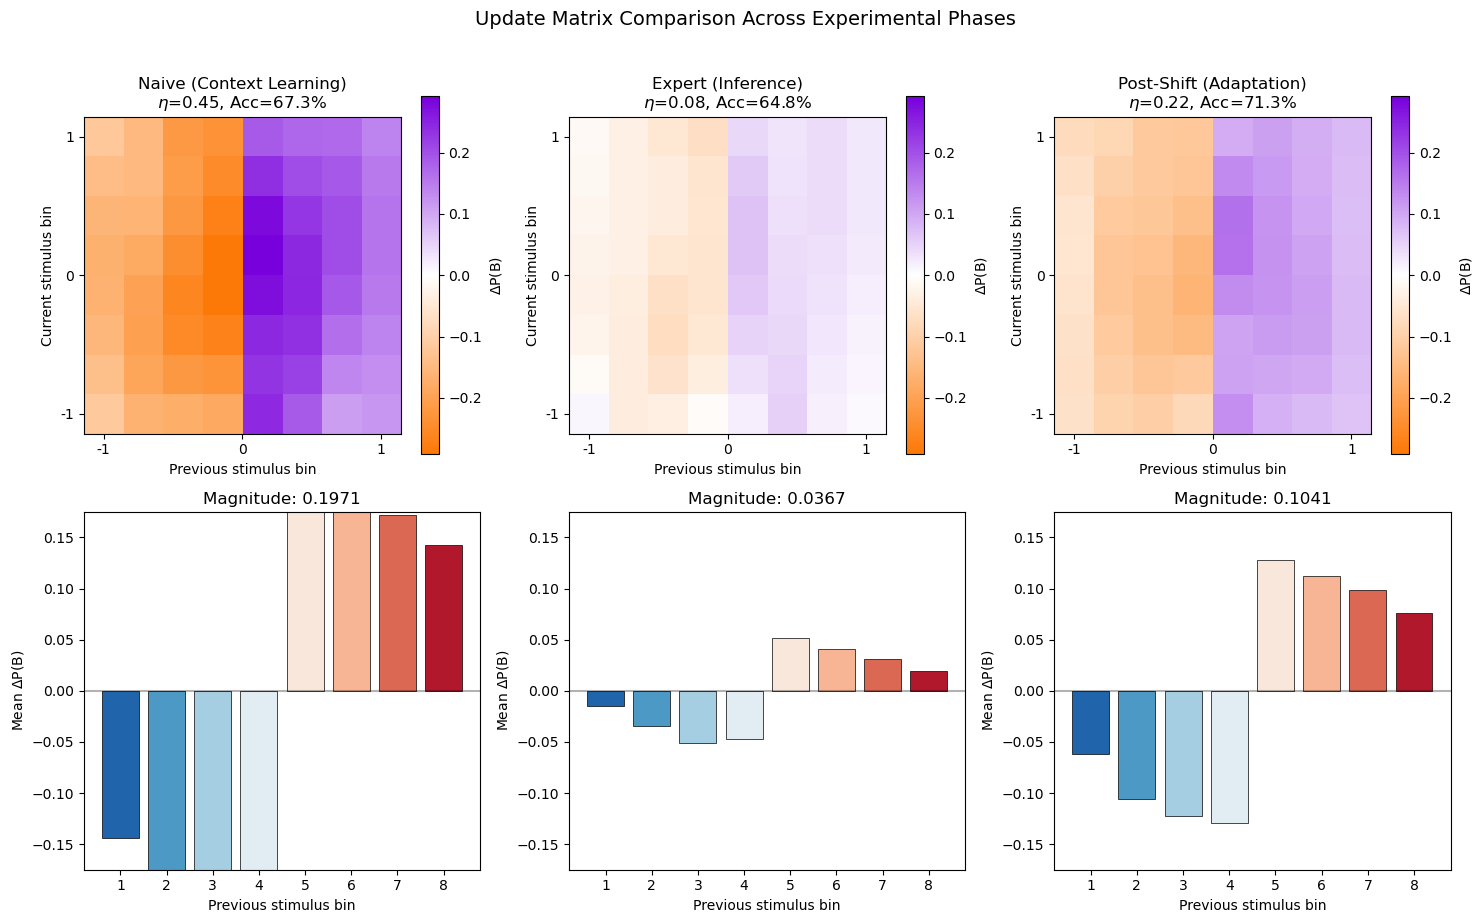

In [9]:
import matplotlib.colors as mcolors
um_cmap = mcolors.LinearSegmentedColormap.from_list(
	'custom_diverging',
	[(253/255, 120/255, 6/255), (1, 1, 1), (120/255, 0/255, 220/255)]
)

def plot_phase_comparison():
	"""
	Plot update matrices for Naive, Expert, and Post-Shift phases side by side.
	"""
	phases = ['Naive (Context Learning)', 'Expert (Inference)', 'Post-Shift (Adaptation)']
	
	fig, axes = plt.subplots(2, 3, figsize=(15, 9))
	
	all_matrices = []
	all_profiles = []
	
	# Compute all matrices first to get common colour scale
	for phase in phases:
		p = PRESETS[phase]
		update_mat, _, _, _, acc, _ = compute_update_matrix_for_params(**p)
		all_matrices.append((phase, update_mat, acc, p))
		all_profiles.append(np.nanmean(update_mat, axis=0))
	
	# Common colour scale
	vmax = max(np.nanmax(np.abs(m[1])) for m in all_matrices)
	if np.isnan(vmax) or vmax == 0:
		vmax = 0.3
	
	# Plot
	for i, (phase, update_mat, acc, p) in enumerate(all_matrices):
		# Top row: Update matrices
		ax = axes[0, i]
		im = ax.imshow(update_mat, cmap=um_cmap, vmin=-vmax, vmax=vmax,
					   origin='lower', aspect='equal')
		ax.set_xlabel('Previous stimulus bin')
		ax.set_ylabel('Current stimulus bin')
		ax.set_title(f"{phase}\n$\\eta$={p['eta_learning']}, Acc={acc:.1%}")
		ax.set_xticks([0, 3.5, 7])
		ax.set_xticklabels(['-1', '0', '1'])
		ax.set_yticks([0, 3.5, 7])
		ax.set_yticklabels(['-1', '0', '1'])
		plt.colorbar(im, ax=ax, label=r'$\Delta$P(B)')
		
		# Bottom row: Profiles
		ax = axes[1, i]
		profile = all_profiles[i]
		bin_indices = np.arange(N_BINS) + 1
		colors = plt.cm.RdBu_r(np.linspace(0.1, 0.9, N_BINS))
		ax.bar(bin_indices, profile, color=colors, edgecolor='black', linewidth=0.5)
		ax.axhline(0, color='k', linestyle='-', alpha=0.3)
		ax.set_xlabel('Previous stimulus bin')
		ax.set_ylabel(r'Mean $\Delta$P(B)')
		magnitude = np.nanmean(np.abs(update_mat))
		ax.set_title(f'Magnitude: {magnitude:.4f}')
		ax.set_xticks(bin_indices)
		ax.set_ylim(-vmax * 0.6, vmax * 0.6)
	
	fig.suptitle('Update Matrix Comparison Across Experimental Phases', fontsize=14, y=1.02)
	plt.tight_layout()
	plt.show()

plot_phase_comparison()

---

## Parameter Sweep

Systematic exploration of how a parameter affects the update matrix.

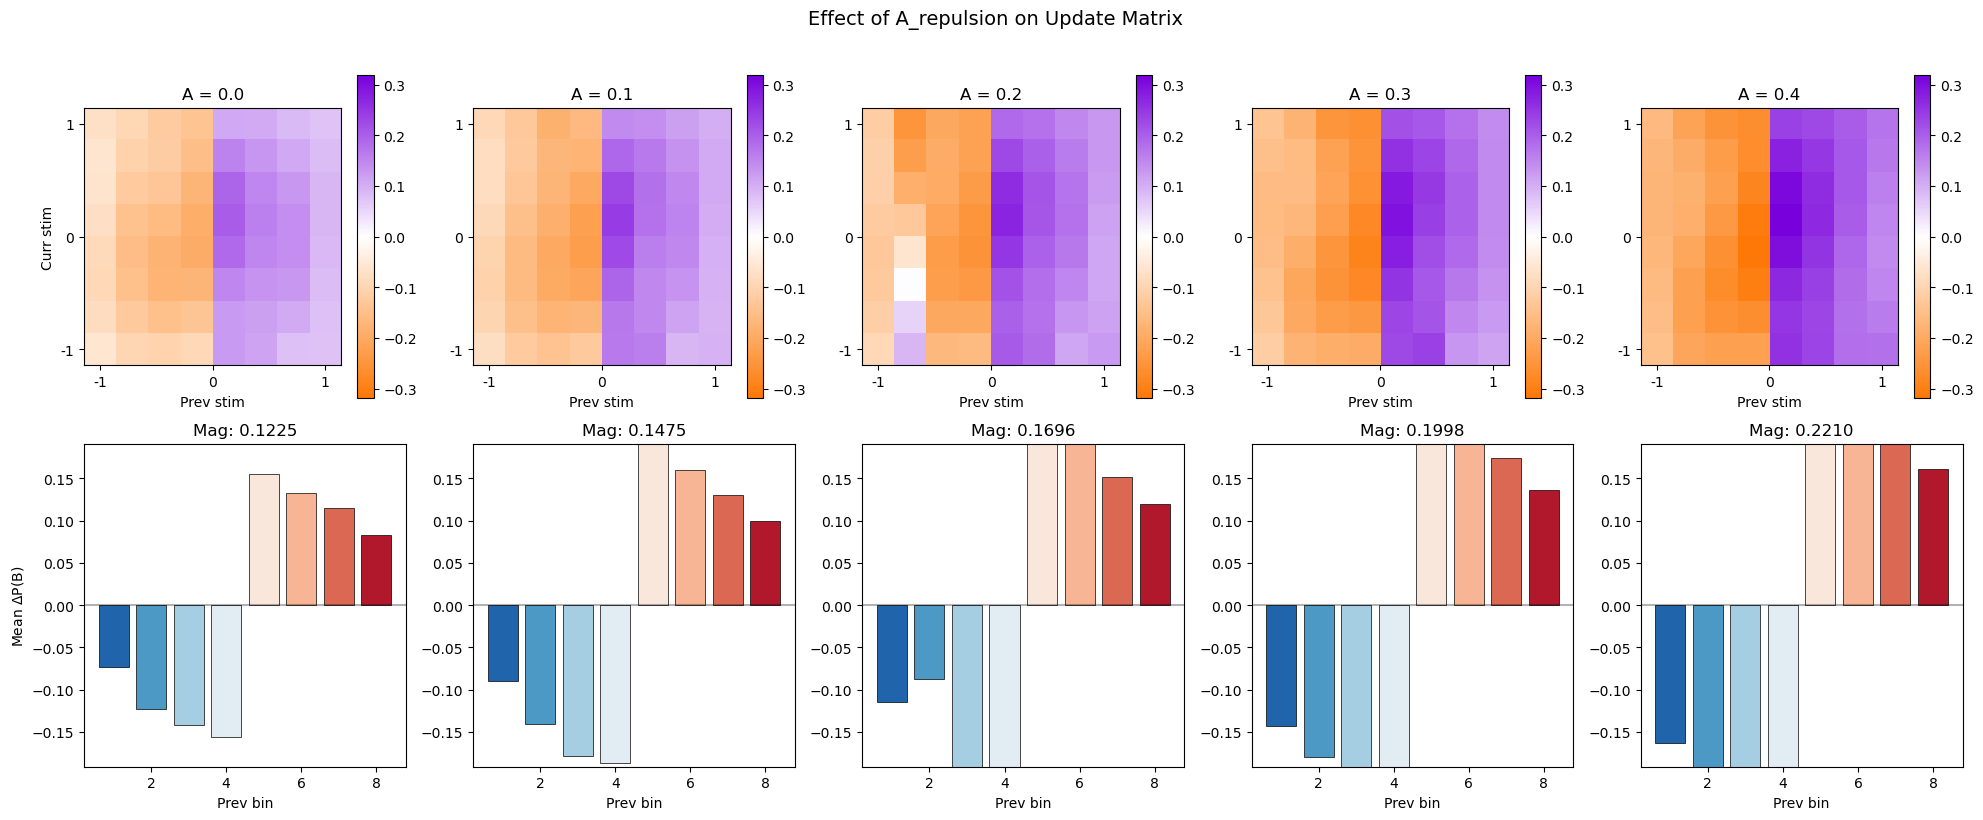

In [ ]:
def plot_param_sweep(param_name='A_repulsion', sweep_values=None, A_repulsion = 0.10, 
					 sigma_percep=0.15, eta_learn=0.35, eta_relax=0.12):
	"""
	Sweep a parameter and show effect on update matrix.
	"""
	if sweep_values is None:
		if param_name == 'A_repulsion':
			sweep_values = [0.0, 0.1, 0.2, 0.3, 0.4]
		elif param_name == 'sigma_percep':
			sweep_values = [0.1, 0.15, 0.2, 0.25, 0.3]
		elif param_name == 'eta_learning':
			sweep_values = [0.1, 0.25, 0.35, 0.5, 0.7]
		elif param_name == 'eta_relax':
			sweep_values = [0.1, 0.15, 0.2, 0.25, 0.3]
	
	
	fig, axes = plt.subplots(2, len(sweep_values), figsize=(4 * len(sweep_values), 8))
	
	all_matrices = []
	magnitudes = []
	
	# Compute all
	for val in sweep_values:
		# Set parameter
		if param_name == 'A_repulsion':
			A_repulsion_session = val
			sig_session = sigma_percep
			eta_learn_session = eta_learn
			eta_relax_session = eta_relax
		elif param_name == 'eta_learning':
			eta_learn_session = val
			A_repulsion_session = A_repulsion
			sig_session = sigma_percep
			eta_relax_session = eta_relax
		elif param_name == 'eta_relax':
			eta_relax_session = val
			A_repulsion_session = A_repulsion
			sig_session = sigma_percep
			eta_learn_session = eta_learn
		elif param_name == 'sigma_percep':
			sig_session = val
			A_repulsion_session = A_repulsion
			eta_learn_session = eta_learn
			eta_relax_session = eta_relax
		
		
		update_mat, _, _, _, acc, _ = compute_update_matrix_for_params(
			sigma_percep=sig_session,
			A_repulsion=A_repulsion_session,
			eta_learning=eta_learn_session,
			eta_relax=eta_relax_session,
		)
		all_matrices.append((val, update_mat, acc))
		magnitudes.append(np.nanmean(np.abs(update_mat)))
	
	# Common colour scale
	vmax = max(np.nanmax(np.abs(m[1])) for m in all_matrices)
	if np.isnan(vmax) or vmax == 0:
		vmax = 0.3
	
	# Plot matrices
	for i, (A, update_mat, acc) in enumerate(all_matrices):
		ax = axes[0, i]
		import matplotlib.colors as mcolors
		um_cmap = mcolors.LinearSegmentedColormap.from_list(
			'custom_diverging',
			[(253/255, 120/255, 6/255), (1, 1, 1), (120/255, 0/255, 220/255)]
		)
		im = ax.imshow(update_mat, cmap=um_cmap, vmin=-vmax, vmax=vmax,
					   origin='lower', aspect='equal')
		ax.set_xlabel('Prev stim')
		if i == 0:
			ax.set_ylabel('Curr stim')
		ax.set_title(f'A = {A}')
		ax.set_xticks([0, 3.5, 7])
		ax.set_xticklabels(['-1', '0', '1'])
		ax.set_yticks([0, 3.5, 7])
		ax.set_yticklabels(['-1', '0', '1'])
		plt.colorbar(im, ax=ax)
		
		# Profile
		ax = axes[1, i]
		profile = np.nanmean(update_mat, axis=0)
		bin_idx = np.arange(N_BINS) + 1
		colors = plt.cm.RdBu_r(np.linspace(0.1, 0.9, N_BINS))
		ax.bar(bin_idx, profile, color=colors, edgecolor='black', linewidth=0.5)
		ax.axhline(0, color='k', alpha=0.3)
		ax.set_xlabel('Prev bin')
		if i == 0:
			ax.set_ylabel(r'Mean $\Delta$P(B)')
		ax.set_title(f'Mag: {magnitudes[i]:.4f}')
		ax.set_ylim(-vmax * 0.6, vmax * 0.6)
	
	fig.suptitle(f'Effect of {param_name} on Update Matrix', fontsize=14, y=1.02)
	plt.tight_layout()
	plt.show()

plot_param_sweep(param_name='A_repulsion', 
                 sweep_values=None, 
                 A_repulsion = 0.10,
                 sigma_percep=0.15, 
                 eta_learn=0.35, 
                 eta_relax=0.12)

---

## 2D Parameter Grid: Full Update Matrices

Visualise the full update matrix for each combination of two parameters.

8 x 8 grid of subplots, each showing an 8 x 8 update matrix.

In [11]:
def compute_update_matrix_grid(
	param1_name: str, param1_values: np.ndarray,
	param2_name: str, param2_values: np.ndarray,
	base_params: dict
):
	"""
	Compute update matrices for a 2D grid of parameters.
	
	Returns:
		matrices: 4D array (n_param2, n_param1, n_bins, n_bins)
	"""
	n1, n2 = len(param1_values), len(param2_values)
	matrices = np.full((n2, n1, N_BINS, N_BINS), np.nan)
	
	total = n1 * n2
	count = 0
	
	for i, p2 in enumerate(param2_values):
		for j, p1 in enumerate(param1_values):
			params = base_params.copy()
			params[param1_name] = p1
			params[param2_name] = p2
			
			try:
				update_mat, _, _, _, _, _ = compute_update_matrix_for_params(**params)
				matrices[i, j] = update_mat
			except Exception as e:
				print(f"Failed at {param1_name}={p1:.2f}, {param2_name}={p2:.2f}: {e}")
			
			count += 1
			if count % 8 == 0:
				print(f"Progress: {count}/{total} ({100*count/total:.0f}%)")
	
	return matrices


def plot_update_matrix_grid(
	param1_name: str, param1_values: np.ndarray,
	param2_name: str, param2_values: np.ndarray,
	base_params: dict,
	param1_label: str = None,
	param2_label: str = None
):
	"""
	Plot 8x8 grid of update matrices for parameter combinations.
	
	Args:
		param1_name: Name of parameter for columns (x-axis)
		param1_values: Array of 8 values for param1
		param2_name: Name of parameter for rows (y-axis)  
		param2_values: Array of 8 values for param2
		base_params: Base parameter dict
		param1_label: Display label for param1 (defaults to param1_name)
		param2_label: Display label for param2 (defaults to param2_name)
	"""
	if param1_label is None:
		param1_label = param1_name
	if param2_label is None:
		param2_label = param2_name
	
	n1, n2 = len(param1_values), len(param2_values)
	
	print(f"Computing {n1}x{n2} = {n1*n2} update matrices...")
	print(f"  {param1_label}: {param1_values}")
	print(f"  {param2_label}: {param2_values}")
	print()
	
	# Compute all matrices
	matrices = compute_update_matrix_grid(
		param1_name, param1_values,
		param2_name, param2_values,
		base_params
	)
	
	# Find global colour scale
	vmax = np.nanmax(np.abs(matrices))
	if np.isnan(vmax) or vmax == 0:
		vmax = 0.3
	vmin = -vmax
	
	# Create figure
	fig, axes = plt.subplots(n2, n1, figsize=(2.2 * n1, 2.2 * n2))
	
	for i in range(n2):  # rows = param2
		for j in range(n1):  # cols = param1
			ax = axes[i, j]  # Flip row order so param2 increases upward
			
			update_mat = matrices[i, j]
			
			import matplotlib.colors as mcolors
			um_cmap = mcolors.LinearSegmentedColormap.from_list(
				'custom_diverging',
				[(253/255, 120/255, 6/255), (1, 1, 1), (120/255, 0/255, 220/255)]
			)
			im = ax.imshow(update_mat, cmap=um_cmap, vmin=vmin, vmax=vmax,
						  origin='lower', aspect='equal')
			
			# Remove tick labels for cleaner look
			ax.set_xticks([])
			ax.set_yticks([])
			
			# Add param values as title/labels for edge subplots
			if i == n2 - 1:  # Bottom row
				ax.set_xlabel(f'{param1_values[j]:.2e}', fontsize=9)
			if j == 0:  # Left column
				ax.set_ylabel(f'{param2_values[i]:.2e}', fontsize=9)
	
	# Add overall axis labels
	fig.text(0.5, 0.02, param1_label, ha='center', fontsize=14)
	fig.text(0.02, 0.5, param2_label, va='center', rotation='vertical', fontsize=14)
	
	# Add colorbar
	cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
	cbar = fig.colorbar(im, cax=cbar_ax)
	cbar.set_label(r'$\Delta$P(B)', fontsize=12)
	
	fig.suptitle(f'Update Matrix Grid: {param1_label} vs {param2_label}', fontsize=14, y=0.98)
	
	plt.subplots_adjust(left=0.08, right=0.9, bottom=0.08, top=0.93, wspace=0.05, hspace=0.05)
	plt.show()
	
	return matrices

Computing 8x8 = 64 update matrices...
  eta_learning: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8]
  A_repulsion: [1.e-05 2.e-05 3.e-05 4.e-05 5.e-05 6.e-05 7.e-05 8.e-05]

Progress: 8/64 (12%)
Progress: 16/64 (25%)
Progress: 24/64 (38%)
Progress: 32/64 (50%)
Progress: 40/64 (62%)
Progress: 48/64 (75%)
Progress: 56/64 (88%)
Progress: 64/64 (100%)


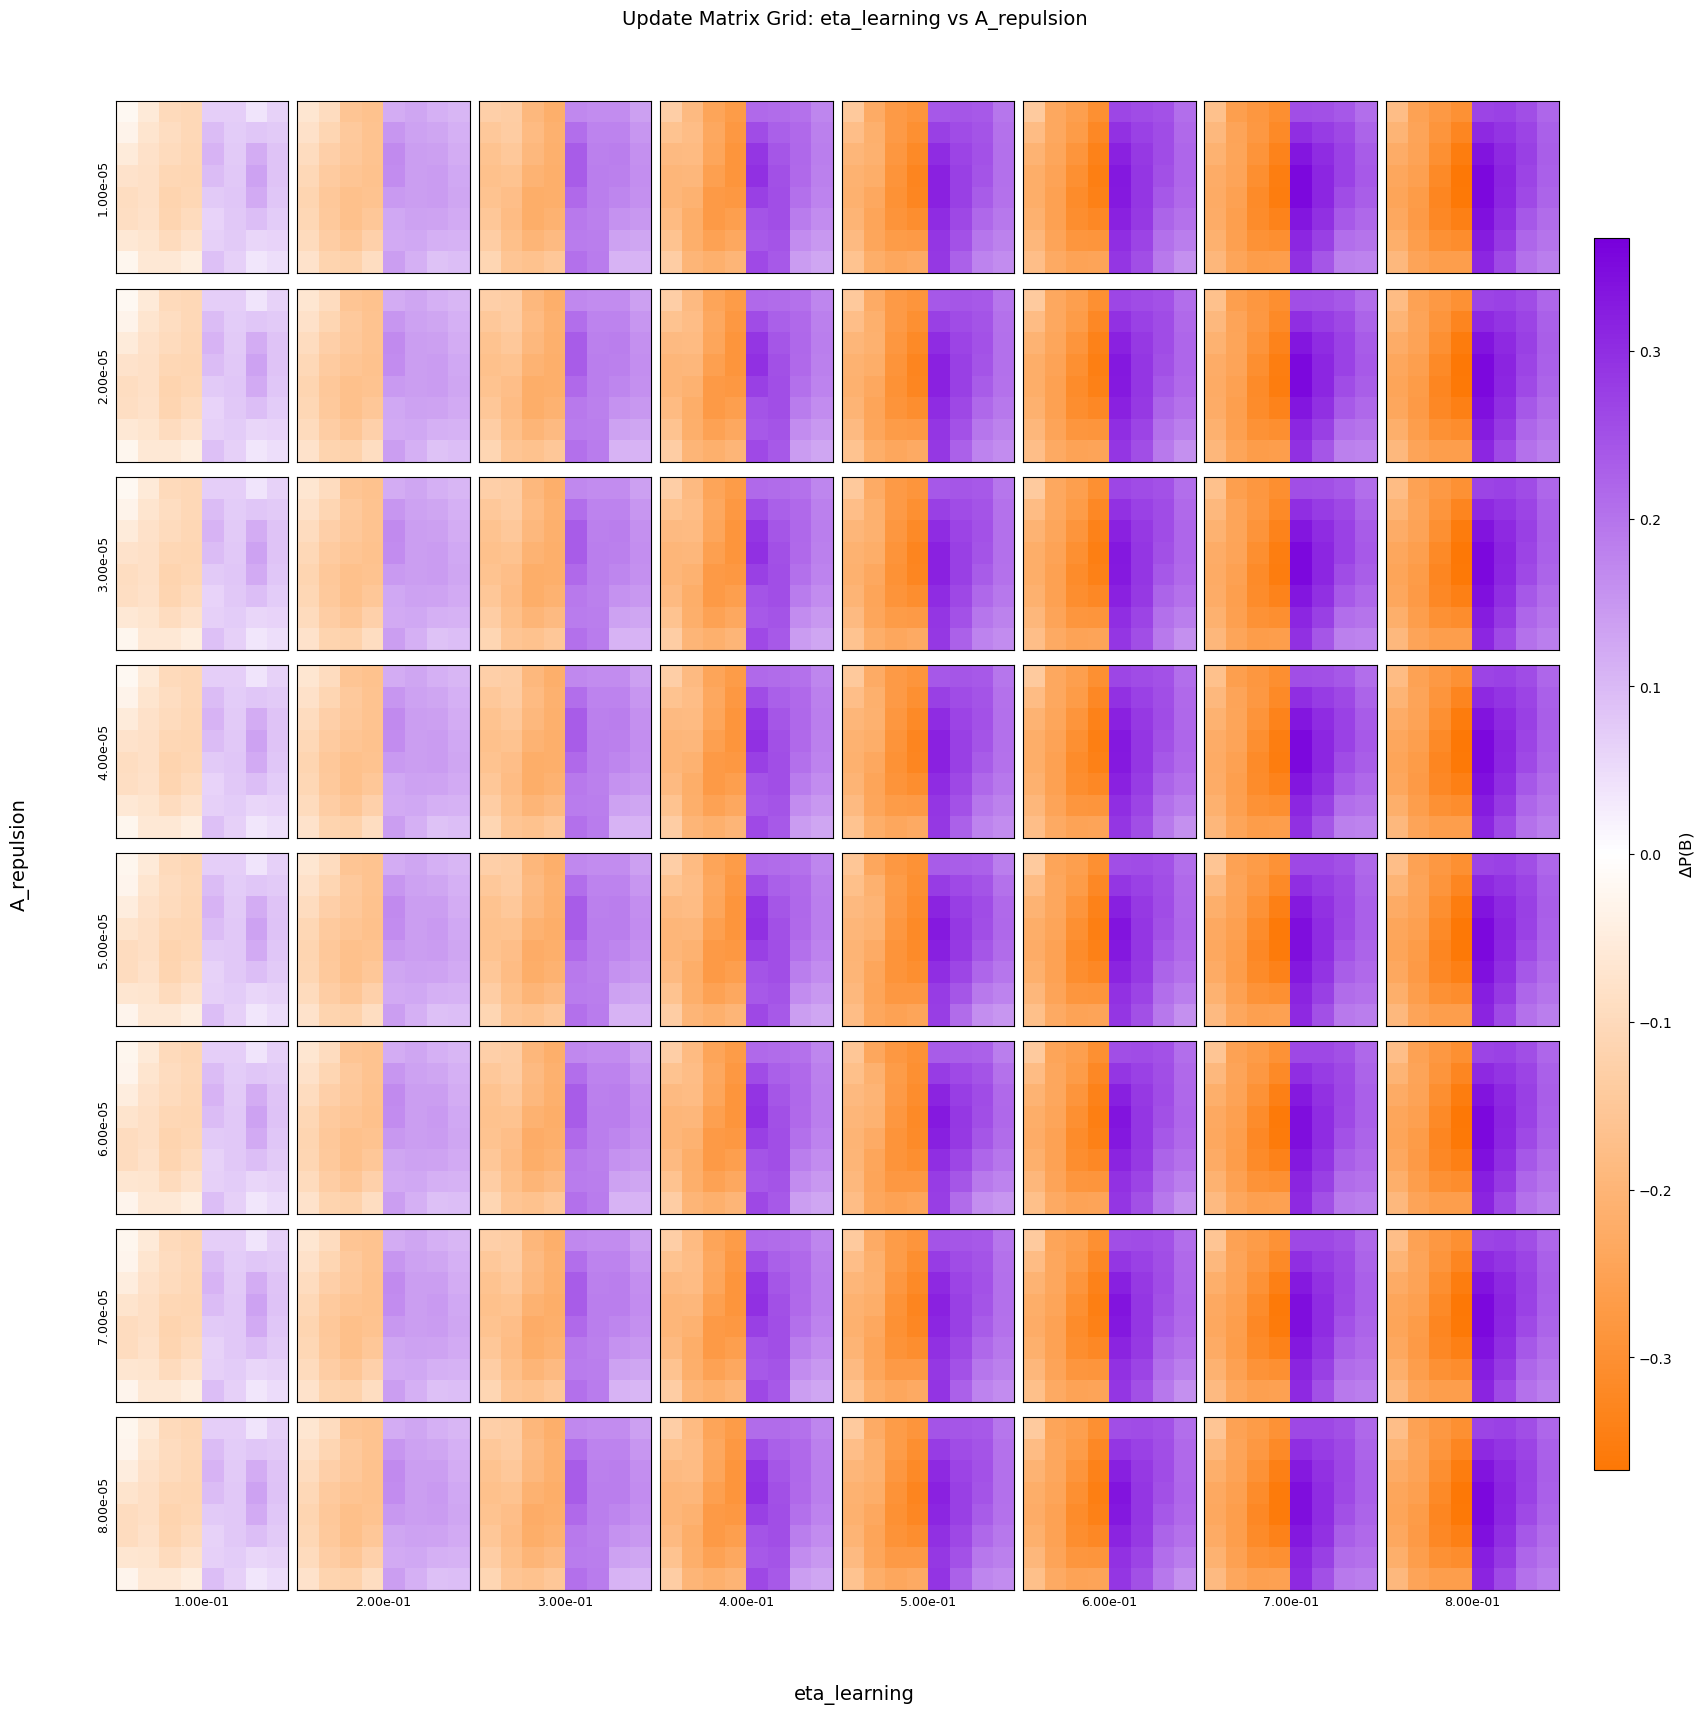

In [12]:
# =============================================================================
# param1 vs param2 (8x8 grid)
# =============================================================================

param_1 = 'eta_learning'
param_2 = 'A_repulsion'
param_1_vals = np.linspace(0.1, 0.8, 8)
param_2_vals = np.linspace(0.1, 0.8, 8)
param_2_vals = np.array([e*0.00001 for e in range(1, 9)])

base_params = {
	'sigma_percep': 0.3,
	'A_repulsion': 0.1,
	'eta_learning': 0.35,  
	'eta_relax': 0.10       
}

matrices_eta = plot_update_matrix_grid(
	param1_name=param_1,
	param1_values=param_1_vals,
	param2_name=param_2,
	param2_values=param_2_vals,
	base_params=base_params,
	param1_label=param_1,
	param2_label=param_2
)

---

## Summary

### Key Findings from Interactive Exploration

1. **Learning rate (Eta_learning)** is the primary driver of update matrix magnitude
	- High Eta_learning --> strong serial dependence (context learning)
	- Low Eta_learning --> weak serial dependence (inference)

2. **Repulsion (A_repulsion)** affects the spatial structure
	- Creates off-diagonal patterns
	- Interacts with learning rate

3. **Relaxation (Eta_relax)** dampens serial dependence
	- Higher relaxation --> faster forgetting --> weaker patterns

4. **Perceptual noise (sigma_percep)** smooths the update matrix
	- Higher noise --> more diffuse patterns


In [13]:
print("Interactive exploration complete!")

Interactive exploration complete!
